### Data Preprocessing

In [1]:
# Set environment paths
import pandas as pd
import numpy as np
import os

# Get the project root directory (two levels up from current directory)
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.getcwd()))
# Define data directory
DATA_DIR = os.path.join(PROJECT_ROOT, "app/data")

# Load CSV files into dataframes
tickets_df = pd.read_csv(os.path.join(DATA_DIR, "tickets.csv"))
# ticket_details_df = pd.read_csv(os.path.join(DATA_DIR, "ticket_details.csv"))

print(f"Loaded {len(tickets_df)} tickets")
# print(f"Loaded {len(ticket_details_df)} ticket details")


Loaded 7296 tickets


In [4]:
# Load the two data sources
under_3k_df = pd.read_csv(os.path.join(DATA_DIR, "ticket_details_under_3k.csv"))
over_4k_diff = pd.read_csv(os.path.join(DATA_DIR, "ticket_details_over_4k.csv"))

# Concatenate the dataframes
ticket_details_df = pd.concat([under_3k_df, over_4k_diff], ignore_index=True)
ticket_details_df.to_csv(os.path.join(DATA_DIR, "complete_ticket_details.csv"), index=False)

In [11]:
tickets_df.head()

,cc_emails,fwd_emails,reply_cc_emails,ticket_cc_emails,ticket_bcc_emails,fr_escalated,spam,email_config_id,group_id,priority,...,due_by,fr_due_by,is_escalated,custom_fields,created_at,updated_at,associated_tickets_count,tags,description,description_text
0,[],[],[],[],[],False,False,5.000016e+09,NaN,1,...,2025-02-25T15:58:25Z,2025-02-23T15:58:25Z,False,{'cf_subscriptions': None},2025-02-22T07:32:05Z,2025-02-22T15:58:25Z,NaN,[],<div>Thank you for signing up with QuotaGuard’...,Thank you for signing up with QuotaGuard’s Sta...
1,"['michael@quotaguard.com', 'randall@quotaguard...",[],"['michael@quotaguard.com', 'randall@quotaguard...",[],[],False,False,5.000016e+09,NaN,1,...,2025-02-24T16:57:51Z,2025-02-22T16:53:26Z,False,{'cf_subscriptions': None},2025-02-21T16:53:26Z,2025-02-21T17:02:04Z,NaN,[],"<div dir=""ltr"">\n<div>Hi Team,</div>\n<div><br...","Hi Team,\r\n\r\nI see QuotaGuard Static IP's\r..."
2,[],[],[],[],[],False,False,5.000016e+09,NaN,1,...,2025-02-23T21:10:52Z,2025-02-21T21:10:52Z,False,{'cf_subscriptions': None},2025-02-20T21:10:52Z,2025-02-20T21:11:57Z,NaN,[],<div>You are currently on a Free Olark account...,You are currently on a Free Olark account. Get...
3,[],[],[],[],[],False,False,5.000016e+09,NaN,1,...,2025-02-25T07:17:19Z,2025-02-20T07:30:45Z,False,{'cf_subscriptions': None},2025-02-19T07:30:45Z,2025-02-22T13:10:39Z,NaN,[],"<div dir=""ltr"">Hi Support Team, <br><br>I'm st...","Hi Support Team,\r\n\r\nI'm still struggling t..."
4,[],[],[],[],[],False,False,5.000016e+09,NaN,1,...,2025-02-24T13:31:27Z,2025-02-19T06:58:04Z,False,{'cf_subscriptions': None},2025-02-18T06:58:04Z,2025-02-21T13:31:28Z,NaN,[],"<div dir=""ltr"">Dear Support Team, <div><br></d...","Dear Support Team,\r\n\r\nI recently purchased..."


In [6]:
tickets_df.shape[0]


7296

In [7]:
ticket_details_df.head()

,cc_emails,fwd_emails,reply_cc_emails,ticket_cc_emails,ticket_bcc_emails,fr_escalated,spam,email_config_id,group_id,priority,...,fr_due_by,is_escalated,description,description_text,custom_fields,created_at,updated_at,tags,attachments,source_additional_info
0,[],[],[],[],[],True,False,NaN,NaN,1,...,2014-03-18T16:00:00Z,True,<div>yeah we don't really login to that accoun...,yeah we don't really login to that account. co...,{'cf_subscriptions': None},2014-03-17T18:58:42Z,2014-09-08T07:19:36Z,[],[],NaN
1,[],[],[],NaN,[],False,False,5.000016e+09,NaN,1,...,2014-09-08T15:00:00Z,False,"<div dir=""ltr"">How does this look</div>\n",How does this look\n,{'cf_subscriptions': None},2014-09-07T20:51:08Z,2014-09-08T07:19:50Z,[],[],NaN
2,['isralog@gmail.com'],[],['isralog@gmail.com'],NaN,[],True,False,NaN,NaN,1,...,2014-10-03T12:17:55Z,True,"<div>Hi, </div>\n<div>i am using soap for node...","Hi, i am using soap for node, and would like...",{'cf_subscriptions': None},2014-10-02T12:17:55Z,2014-10-09T19:11:00Z,[],[],NaN
3,[],[],[],NaN,[],False,False,5.000016e+09,NaN,1,...,2014-10-17T08:15:31Z,False,<div>I’m trying to find a static IP service to...,I'm trying to find a static IP service to use ...,{'cf_subscriptions': None},2014-10-12T16:39:56Z,2014-10-16T08:26:39Z,[],[],NaN
4,[],[],[],NaN,[],False,False,NaN,NaN,1,...,2014-10-14T11:43:55Z,False,"<div>Hi,</div>\n<div>how can i do that thing&g...","Hi, how can i do that thing> Thanks.",{'cf_subscriptions': None},2014-10-13T11:43:55Z,2014-10-13T11:44:25Z,[],[],NaN


In [8]:
ticket_details_df.describe()

,email_config_id,group_id,priority,requester_id,responder_id,source,company_id,status,association_type,product_id,id,source_additional_info
count,5.421000e+03,8.200000e+01,6210.000000,6.210000e+03,3.310000e+03,6210.000000,4.000000e+00,6210.000000,0.0,9.320000e+02,6210.000000,0.0
mean,5.018101e+09,5.512240e+09,1.010145,1.143269e+10,9.113496e+09,1.731562,1.200032e+10,5.000161,NaN,5.105153e+09,3946.610467,NaN
std,3.553037e+08,1.834123e+09,0.139230,1.964989e+09,3.462807e+09,1.998127,3.011783e+04,0.012690,NaN,8.519232e+08,2535.186316,NaN
min,5.000016e+09,5.000047e+09,1.000000,5.000422e+09,5.021538e+09,1.000000,1.200030e+10,5.000000,NaN,5.000003e+09,3.000000,NaN
25%,5.000016e+09,5.000047e+09,1.000000,1.201225e+10,5.021538e+09,1.000000,1.200030e+10,5.000000,NaN,5.000003e+09,1591.250000,NaN
50%,5.000016e+09,5.000048e+09,1.000000,1.203179e+10,1.203734e+10,1.000000,1.200032e+10,5.000000,NaN,5.000003e+09,4387.500000,NaN
75%,5.000016e+09,5.000048e+09,1.000000,1.205050e+10,1.203734e+10,2.000000,1.200035e+10,5.000000,NaN,5.000003e+09,6148.750000,NaN
max,1.200000e+10,1.200001e+10,4.000000,1.206052e+10,1.205545e+10,10.000000,1.200035e+10,6.000000,NaN,1.200000e+10,8236.000000,NaN


In [9]:
# Set the ID column as the index
ticket_details_df.set_index('id', inplace=True)
ticket_details_df.head()

,cc_emails,fwd_emails,reply_cc_emails,ticket_cc_emails,ticket_bcc_emails,fr_escalated,spam,email_config_id,group_id,priority,...,fr_due_by,is_escalated,description,description_text,custom_fields,created_at,updated_at,tags,attachments,source_additional_info
id,,,,,,,,,,,,,,,,,,,,,
4,[],[],[],[],[],True,False,NaN,NaN,1,...,2014-03-18T16:00:00Z,True,<div>yeah we don't really login to that accoun...,yeah we don't really login to that account. co...,{'cf_subscriptions': None},2014-03-17T18:58:42Z,2014-09-08T07:19:36Z,[],[],NaN
3,[],[],[],NaN,[],False,False,5.000016e+09,NaN,1,...,2014-09-08T15:00:00Z,False,"<div dir=""ltr"">How does this look</div>\n",How does this look\n,{'cf_subscriptions': None},2014-09-07T20:51:08Z,2014-09-08T07:19:50Z,[],[],NaN
8,['isralog@gmail.com'],[],['isralog@gmail.com'],NaN,[],True,False,NaN,NaN,1,...,2014-10-03T12:17:55Z,True,"<div>Hi, </div>\n<div>i am using soap for node...","Hi, i am using soap for node, and would like...",{'cf_subscriptions': None},2014-10-02T12:17:55Z,2014-10-09T19:11:00Z,[],[],NaN
9,[],[],[],NaN,[],False,False,5.000016e+09,NaN,1,...,2014-10-17T08:15:31Z,False,<div>I’m trying to find a static IP service to...,I'm trying to find a static IP service to use ...,{'cf_subscriptions': None},2014-10-12T16:39:56Z,2014-10-16T08:26:39Z,[],[],NaN
10,[],[],[],NaN,[],False,False,NaN,NaN,1,...,2014-10-14T11:43:55Z,False,"<div>Hi,</div>\n<div>how can i do that thing&g...","Hi, how can i do that thing> Thanks.",{'cf_subscriptions': None},2014-10-13T11:43:55Z,2014-10-13T11:44:25Z,[],[],NaN


### Consistent Data Types & Missing Values


In [10]:
# Convert timestamps to datetime
for col in ['created_at', 'updated_at']:
    tickets_df[col] = pd.to_datetime(tickets_df[col])
    ticket_details_df[col] = pd.to_datetime(ticket_details_df[col])
# Calculate basic time-related features
ticket_details_df['response_time_hours'] = (ticket_details_df['updated_at'] - ticket_details_df['created_at']).dt.total_seconds() / 3600
ticket_details_df['created_date'] = ticket_details_df['created_at'].dt.date
ticket_details_df['created_hour'] = ticket_details_df['created_at'].dt.hour
ticket_details_df['created_day_of_week'] = ticket_details_df['created_at'].dt.day_name()

print("\n=== Ticket Details DataFrame Data Types ===")
print(ticket_details_df.dtypes)

print("\n=== Missing Values in Ticket Details DataFrame ===")
print(ticket_details_df.isnull().sum())


=== Ticket Details DataFrame Data Types ===
cc_emails                              object
fwd_emails                             object
reply_cc_emails                        object
ticket_cc_emails                       object
ticket_bcc_emails                      object
fr_escalated                             bool
spam                                     bool
email_config_id                       float64
group_id                              float64
priority                                int64
requester_id                            int64
responder_id                          float64
source                                  int64
company_id                            float64
status                                  int64
subject                                object
association_type                      float64
support_email                          object
to_emails                              object
product_id                            float64
type                               

In [11]:
# First, let's look at the unique values in each column
print("=== Column Value Counts ===")
for column in ticket_details_df.columns:
    n_unique = ticket_details_df[column].nunique()
    print(f"\n{column}: {n_unique} unique values")
    
    # For columns with reasonable number of unique values, show distribution
    if n_unique < 10 and n_unique > 0:
        print(ticket_details_df[column].value_counts())

# Check for any duplicate entries
print("\n=== Duplicate Check ===")
print(f"Number of duplicate rows: {ticket_details_df.duplicated().sum()}")


=== Column Value Counts ===

cc_emails: 774 unique values

fwd_emails: 8 unique values
fwd_emails
[]                                             6202
['scaling-squad@panoramaed.com']                  2
['craig.cox@borrowell.com']                       1
['"Michael Frew" <owner@quotaguardco.com>']       1
['michael@michaelfrew.com']                       1
['againstgrav@gmail.com']                         1
['michael@quotaguard.com']                        1
['andrew@quotebeam.com']                          1
Name: count, dtype: int64

reply_cc_emails: 699 unique values

ticket_cc_emails: 473 unique values

ticket_bcc_emails: 1 unique values
ticket_bcc_emails
[]    6071
Name: count, dtype: int64

fr_escalated: 2 unique values
fr_escalated
False    6035
True      175
Name: count, dtype: int64

spam: 1 unique values
spam
False    6210
Name: count, dtype: int64

email_config_id: 6 unique values
email_config_id
5.000016e+09    4489
5.000056e+09     512
5.000056e+09     327
5.000056e+09     

In [12]:
# Basic statistics for numeric columns
numeric_columns = ticket_details_df.select_dtypes(include=['int64', 'float64']).columns
print("\n=== Numeric Column Statistics ===")
print(ticket_details_df[numeric_columns].describe())

# Check for any potential data quality issues
print("\n=== Data Quality Checks ===")
# Check for any negative values in numeric columns
for col in numeric_columns:
    neg_count = (ticket_details_df[col] < 0).sum()
    if neg_count > 0:
        print(f"Found {neg_count} negative values in {col}")



=== Numeric Column Statistics ===
       email_config_id      group_id     priority  requester_id  responder_id  \
count     5.421000e+03  8.200000e+01  6210.000000  6.210000e+03  3.310000e+03   
mean      5.018101e+09  5.512240e+09     1.010145  1.143269e+10  9.113496e+09   
std       3.553037e+08  1.834123e+09     0.139230  1.964989e+09  3.462807e+09   
min       5.000016e+09  5.000047e+09     1.000000  5.000422e+09  5.021538e+09   
25%       5.000016e+09  5.000047e+09     1.000000  1.201225e+10  5.021538e+09   
50%       5.000016e+09  5.000048e+09     1.000000  1.203179e+10  1.203734e+10   
75%       5.000016e+09  5.000048e+09     1.000000  1.205050e+10  1.203734e+10   
max       1.200000e+10  1.200001e+10     4.000000  1.206052e+10  1.205545e+10   

            source    company_id       status  association_type    product_id  \
count  6210.000000  4.000000e+00  6210.000000               0.0  9.320000e+02   
mean      1.731562  1.200032e+10     5.000161               NaN  5.105153

In [13]:
# Get list of numeric columns for analysis
string_id_cols = [
    'email_config_id',
    'requester_id',
    'responder_id',
    'product_id',
    'company_id',
    'group_id',
    'email_config_id'
]

# Convert int64 columns to string
# First, let's identify which columns are int64
int_columns = ticket_details_df[string_id_cols].columns
print("Columns being converted from int64 to string:", int_columns.tolist())

# Convert those columns to string
for col in int_columns:
    ticket_details_df[col] = ticket_details_df[col].astype(str)

# Verify the conversion
print("\nNew data types after conversion:")
print(ticket_details_df[int_columns].dtypes)

print("\n Let's check the unique data types in the columns")
print(ticket_details_df[int_columns].describe())



Columns being converted from int64 to string: ['email_config_id', 'requester_id', 'responder_id', 'product_id', 'company_id', 'group_id', 'email_config_id']

New data types after conversion:
email_config_id    object
requester_id       object
responder_id       object
product_id         object
company_id         object
group_id           object
email_config_id    object
dtype: object

 Let's check the unique data types in the columns
       email_config_id requester_id responder_id product_id company_id  \
count             6210         6210         6210       6210       6210   
unique               7         3798            5          6          4   
top       5000016478.0  12018372789          nan        nan        nan   
freq              4489           64         2900       5278       6206   

       group_id email_config_id  
count      6210            6210  
unique        4               7  
top         nan    5000016478.0  
freq       6128            4489  


In [14]:
# Check for future dates in timestamp columns
current_date = pd.Timestamp.now(tz='UTC')
for col in ['created_at', 'updated_at']:
    # Convert column to UTC if it isn't already
    if ticket_details_df[col].dt.tz is None:
        ticket_details_df[col] = ticket_details_df[col].dt.tz_localize('UTC')
    future_dates = ticket_details_df[col].dt.tz_localize(None) > current_date.tz_localize(None)
    if future_dates.sum() > 0:
        print(f"Found {future_dates.sum()} future dates in {col}")

### Categorical Values

In [15]:
# Create mappings for priority and status
priority_map = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Urgent'
}

status_map = {
    2: 'Open',
    3: 'Pending',
    4: 'Resolved',
    5: 'Closed',
    6: 'Waiting on Customer',
    7: 'Waiting on Third Party'
}

# Create mapping for source
source_map = {
    1: 'Email',
    2: 'Portal',
    3: 'Phone',
    7: 'Chat',
    9: 'Feedback Widget',
    10: 'Outbound Email'
}

# Convert priority to categorical with ordered levels
ticket_details_df['priority_category'] = (ticket_details_df['priority']
                                        .map(priority_map)
                                        .astype('category'))

# Set the priority category order
ticket_details_df['priority_category'] = (ticket_details_df['priority_category']
                                        .cat.set_categories(['Low', 'Medium', 'High', 'Urgent'], 
                                                          ordered=True))

# Convert status to categorical
ticket_details_df['status_category'] = (ticket_details_df['status']
                                      .map(status_map)
                                      .astype('category'))

# Convert source to categorical
ticket_details_df['source_category'] = (ticket_details_df['source']
                                      .map(source_map)
                                      .astype('category'))


# Verify the conversions
print("=== Priority Categories ===")
print(ticket_details_df['priority_category'].value_counts().sort_index())
print("\n=== Status Categories ===")
print(ticket_details_df['status_category'].value_counts())
print("=== Source Categories ===")
print(ticket_details_df['source_category'].value_counts())


# Check for any unmapped values
print("\n=== Checking for Unmapped Values ===")
print("Priority unmapped:", ticket_details_df[ticket_details_df['priority_category'].isna()]['priority'].unique())
print("Status unmapped:", ticket_details_df[ticket_details_df['status_category'].isna()]['status'].unique())
unmapped_sources = ticket_details_df[ticket_details_df['source_category'].isna()]['source'].unique()
print("Source unmapped:", unmapped_sources if len(unmapped_sources) > 0 else "None")

=== Priority Categories ===
priority_category
Low       6173
Medium      14
High        20
Urgent       3
Name: count, dtype: int64

=== Status Categories ===
status_category
Closed                 6209
Waiting on Customer       1
Name: count, dtype: int64
=== Source Categories ===
source_category
Email              4511
Portal             1267
Feedback Widget     230
Outbound Email      146
Phone                53
Chat                  2
Name: count, dtype: int64

=== Checking for Unmapped Values ===
Priority unmapped: []
Status unmapped: []
Source unmapped: [5]


### Boolean Values

In [16]:
# Identify boolean columns
bool_columns = [
    'spam',
    'fr_escalated',
    'is_escalated',
]

# Basic analysis of boolean features
print("=== Boolean Features Analysis ===")
for col in bool_columns:
    value_counts = ticket_details_df[col].value_counts()
    percentages = ticket_details_df[col].value_counts(normalize=True) * 100
    
    print(f"\n{col.replace('_', ' ').title()}:")
    print(f"True count: {value_counts.get(True, 0)} ({percentages.get(True, 0):.2f}%)")
    print(f"False count: {value_counts.get(False, 0)} ({percentages.get(False, 0):.2f}%)")
    print(f"Missing values: {ticket_details_df[col].isna().sum()}")

# Cross-tabulation with priority categories
print("\n=== Boolean Features by Priority ===")
for col in bool_columns:
    print(f"\n{col.replace('_', ' ').title()} by Priority:")
    print(pd.crosstab(ticket_details_df[col], 
                      ticket_details_df['priority_category'], 
                      normalize='columns') * 100)

# Cross-tabulation with status categories
print("\n=== Boolean Features by Status ===")
for col in bool_columns:
    print(f"\n{col.replace('_', ' ').title()} by Status:")
    print(pd.crosstab(ticket_details_df[col], 
                      ticket_details_df['status_category'], 
                      normalize='columns') * 100)

# Check for correlations between boolean features
print("\n=== Correlations Between Boolean Features ===")
bool_correlations = ticket_details_df[bool_columns].corr()
print(bool_correlations)

# Find significant correlations (|correlation| > 0.3)
print("\n=== Significant Boolean Correlations (|correlation| > 0.3) ===")
for col1 in bool_columns:
    for col2 in bool_columns:
        if col1 < col2:  # avoid printing both (a,b) and (b,a)
            corr = bool_correlations.loc[col1, col2]
            if abs(corr) > 0.3:
                print(f"{col1} vs {col2}: {corr:.3f}")


=== Boolean Features Analysis ===

Spam:
True count: 0 (0.00%)
False count: 6210 (100.00%)
Missing values: 0

Fr Escalated:
True count: 175 (2.82%)
False count: 6035 (97.18%)
Missing values: 0

Is Escalated:
True count: 489 (7.87%)
False count: 5721 (92.13%)
Missing values: 0

=== Boolean Features by Priority ===

Spam by Priority:
priority_category    Low  Medium   High  Urgent
spam                                           
False              100.0   100.0  100.0   100.0

Fr Escalated by Priority:
priority_category        Low     Medium  High  Urgent
fr_escalated                                         
False              97.197473  92.857143  95.0   100.0
True                2.802527   7.142857   5.0     0.0

Is Escalated by Priority:
priority_category        Low     Medium  High  Urgent
is_escalated                                         
False              92.224202  85.714286  65.0   100.0
True                7.775798  14.285714  35.0     0.0

=== Boolean Features by Status ===


### Time to Close Analysis


In [17]:
# Calculate time to close in hours
ticket_details_df['time_to_close_hours'] = (ticket_details_df['updated_at'] - ticket_details_df['created_at']).dt.total_seconds() / 3600

# Create a new column for time to close in days
ticket_details_df['time_to_close_days'] = (ticket_details_df['updated_at'] - ticket_details_df['created_at']).dt.days

print(ticket_details_df['time_to_close_hours'].describe())
print(ticket_details_df['time_to_close_days'].describe())

count     6210.000000
mean       311.264785
std       1476.427064
min          0.000000
25%          1.894167
50%         49.435694
75%        133.513681
max      44507.084444
Name: time_to_close_hours, dtype: float64
count    6210.000000
mean       12.673269
std        61.484125
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max      1854.000000
Name: time_to_close_days, dtype: float64


In [18]:
# Calculate time to close/resolve tickets
ticket_details_df['time_to_close'] = (ticket_details_df['updated_at'] - ticket_details_df['created_at']).dt.total_seconds() / 3600  # in hours

# Basic statistics for time to close
print("=== Time to Close Statistics (in hours) ===")
print(ticket_details_df['time_to_close'].describe())

# Calculate business metrics
print("\n=== Business Time Metrics ===")
print(f"Average time to close: {ticket_details_df['time_to_close'].mean():.2f} hours")
print(f"Median time to close: {ticket_details_df['time_to_close'].median():.2f} hours")
print(f"90th percentile: {ticket_details_df['time_to_close'].quantile(0.9):.2f} hours")
print(f"95th percentile: {ticket_details_df['time_to_close'].quantile(0.95):.2f} hours")

# Time to close by priority
print("\n=== Time to Close by Priority ===")
priority_stats = ticket_details_df.groupby('priority_category')['time_to_close'].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)
print(priority_stats)

# Time to close by source
print("\n=== Time to Close by Source ===")
source_stats = ticket_details_df.groupby('source_category')['time_to_close'].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)
print(source_stats)


# Calculate time bands for tickets
ticket_details_df['time_band'] = pd.cut(
    ticket_details_df['time_to_close'],
    bins=[0, 1, 4, 24, 72, float('inf')],
    labels=['< 1 hour', '1-4 hours', '4-24 hours', '1-3 days', '> 3 days']
)

print("\n=== Distribution of Time Bands ===")
time_band_dist = ticket_details_df['time_band'].value_counts().sort_index()
print(time_band_dist)

# Correlation with numeric features
numeric_cols = ['requester_id', 'responder_id', 'group_id', 'priority']
print("\n=== Correlation with Numeric Features ===")
correlations = ticket_details_df[numeric_cols + ['time_to_close']].corr()['time_to_close']
print(correlations)

# Analysis by boolean features
print("\n=== Average Time to Close by Boolean Features ===")
bool_cols = ['spam', 'fr_escalated', 'is_escalated']
for col in bool_cols:
    avg_time = ticket_details_df.groupby(col)['time_to_close'].mean()
    print(f"\n{col}:")
    print(avg_time)

# Time of day analysis
ticket_details_df['created_hour'] = ticket_details_df['created_at'].dt.hour
print("\n=== Average Time to Close by Hour of Day Ticket Created===")
hour_stats = ticket_details_df.groupby('created_hour')['time_to_close'].agg([
    'count',
    'mean',
    'median'
]).round(2)
print(hour_stats)

# Day of week analysis
ticket_details_df['created_day'] = ticket_details_df['created_at'].dt.day_name()
print("\n=== Average Time to Close by Day of Week Ticket Created===")
day_stats = ticket_details_df.groupby('created_day')['time_to_close'].agg([
    'count',
    'mean',
    'median'
]).round(2)
print(day_stats)

=== Time to Close Statistics (in hours) ===
count     6210.000000
mean       311.264785
std       1476.427064
min          0.000000
25%          1.894167
50%         49.435694
75%        133.513681
max      44507.084444
Name: time_to_close, dtype: float64

=== Business Time Metrics ===
Average time to close: 311.26 hours
Median time to close: 49.44 hours
90th percentile: 494.31 hours
95th percentile: 1168.59 hours

=== Time to Close by Priority ===
                   count    mean  median      std
priority_category                                
Low                 6173  309.17   49.38  1470.37
Medium                14  331.82  122.41   454.02
High                  20  989.74   57.27  3065.66
Urgent                 3    0.26    0.27     0.02

=== Time to Close by Source ===
                 count    mean  median      std
source_category                                
Chat                 2    0.06    0.06     0.08
Email             4511  314.07   50.79  1561.10
Feedback Widget    230

/var/folders/nd/z10gkxp14_vbcbgjmpzd69200000gn/T/ipykernel_1491/3201008526.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  priority_stats = ticket_details_df.groupby('priority_category')['time_to_close'].agg([
/var/folders/nd/z10gkxp14_vbcbgjmpzd69200000gn/T/ipykernel_1491/3201008526.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  source_stats = ticket_details_df.groupby('source_category')['time_to_close'].agg([


In [19]:
# Identify boolean columns
bool_columns = [
    'spam',
    'fr_escalated',
    'is_escalated',
]

# Basic analysis of boolean features
print("=== Boolean Features Analysis ===")
for col in bool_columns:
    value_counts = ticket_details_df[col].value_counts()
    percentages = ticket_details_df[col].value_counts(normalize=True) * 100
    
    print(f"\n{col.replace('_', ' ').title()}:")
    print(f"True count: {value_counts.get(True, 0)} ({percentages.get(True, 0):.2f}%)")
    print(f"False count: {value_counts.get(False, 0)} ({percentages.get(False, 0):.2f}%)")
    print(f"Missing values: {ticket_details_df[col].isna().sum()}")

# Cross-tabulation with priority categories
print("\n=== Boolean Features by Priority ===")
for col in bool_columns:
    print(f"\n{col.replace('_', ' ').title()} by Priority:")
    print(pd.crosstab(ticket_details_df[col], 
                      ticket_details_df['priority_category'], 
                      normalize='columns') * 100)

# Cross-tabulation with status categories
print("\n=== Boolean Features by Status ===")
for col in bool_columns:
    print(f"\n{col.replace('_', ' ').title()} by Status:")
    print(pd.crosstab(ticket_details_df[col], 
                      ticket_details_df['status_category'], 
                      normalize='columns') * 100)

# Check for correlations between boolean features
print("\n=== Correlations Between Boolean Features ===")
bool_correlations = ticket_details_df[bool_columns].corr()
print(bool_correlations)

# Find significant correlations (|correlation| > 0.3)
print("\n=== Significant Boolean Correlations (|correlation| > 0.3) ===")
for col1 in bool_columns:
    for col2 in bool_columns:
        if col1 < col2:  # avoid printing both (a,b) and (b,a)
            corr = bool_correlations.loc[col1, col2]
            if abs(corr) > 0.3:
                print(f"{col1} vs {col2}: {corr:.3f}")

=== Boolean Features Analysis ===

Spam:
True count: 0 (0.00%)
False count: 6210 (100.00%)
Missing values: 0

Fr Escalated:
True count: 175 (2.82%)
False count: 6035 (97.18%)
Missing values: 0

Is Escalated:
True count: 489 (7.87%)
False count: 5721 (92.13%)
Missing values: 0

=== Boolean Features by Priority ===

Spam by Priority:
priority_category    Low  Medium   High  Urgent
spam                                           
False              100.0   100.0  100.0   100.0

Fr Escalated by Priority:
priority_category        Low     Medium  High  Urgent
fr_escalated                                         
False              97.197473  92.857143  95.0   100.0
True                2.802527   7.142857   5.0     0.0

Is Escalated by Priority:
priority_category        Low     Medium  High  Urgent
is_escalated                                         
False              92.224202  85.714286  65.0   100.0
True                7.775798  14.285714  35.0     0.0

=== Boolean Features by Status ===


In [20]:
# Calculate time to close/resolve tickets
ticket_details_df['time_to_close'] = (ticket_details_df['updated_at'] - ticket_details_df['created_at']).dt.total_seconds() / 3600  # in hours

# Basic statistics for time to close
print("=== Time to Close Statistics (in hours) ===")
print(ticket_details_df['time_to_close'].describe())

# Calculate business metrics
print("\n=== Business Time Metrics ===")
print(f"Average time to close: {ticket_details_df['time_to_close'].mean():.2f} hours")
print(f"Median time to close: {ticket_details_df['time_to_close'].median():.2f} hours")
print(f"90th percentile: {ticket_details_df['time_to_close'].quantile(0.9):.2f} hours")
print(f"95th percentile: {ticket_details_df['time_to_close'].quantile(0.95):.2f} hours")

# Time to close by priority
print("\n=== Time to Close by Priority ===")
priority_stats = ticket_details_df.groupby('priority_category')['time_to_close'].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)
print(priority_stats)

# Time to close by source
print("\n=== Time to Close by Source ===")
source_stats = ticket_details_df.groupby('source_category')['time_to_close'].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)
print(source_stats)


# Calculate time bands for tickets
ticket_details_df['time_band'] = pd.cut(
    ticket_details_df['time_to_close'],
    bins=[0, 1, 4, 24, 72, float('inf')],
    labels=['< 1 hour', '1-4 hours', '4-24 hours', '1-3 days', '> 3 days']
)

print("\n=== Distribution of Time Bands ===")
time_band_dist = ticket_details_df['time_band'].value_counts().sort_index()
print(time_band_dist)

# Correlation with numeric features
numeric_cols = ['requester_id', 'responder_id', 'group_id', 'priority']
print("\n=== Correlation with Numeric Features ===")
correlations = ticket_details_df[numeric_cols + ['time_to_close']].corr()['time_to_close']
print(correlations)

# Analysis by boolean features
print("\n=== Average Time to Close by Boolean Features ===")
bool_cols = ['spam', 'fr_escalated', 'is_escalated']
for col in bool_cols:
    avg_time = ticket_details_df.groupby(col)['time_to_close'].mean()
    print(f"\n{col}:")
    print(avg_time)

# Time of day analysis
ticket_details_df['created_hour'] = ticket_details_df['created_at'].dt.hour
print("\n=== Average Time to Close by Hour of Day Ticket Created===")
hour_stats = ticket_details_df.groupby('created_hour')['time_to_close'].agg([
    'count',
    'mean',
    'median'
]).round(2)
print(hour_stats)

# Day of week analysis
ticket_details_df['created_day'] = ticket_details_df['created_at'].dt.day_name()
print("\n=== Average Time to Close by Day of Week Ticket Created===")
day_stats = ticket_details_df.groupby('created_day')['time_to_close'].agg([
    'count',
    'mean',
    'median'
]).round(2)
print(day_stats)

=== Time to Close Statistics (in hours) ===
count     6210.000000
mean       311.264785
std       1476.427064
min          0.000000
25%          1.894167
50%         49.435694
75%        133.513681
max      44507.084444
Name: time_to_close, dtype: float64

=== Business Time Metrics ===
Average time to close: 311.26 hours
Median time to close: 49.44 hours


/var/folders/nd/z10gkxp14_vbcbgjmpzd69200000gn/T/ipykernel_1491/3201008526.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  priority_stats = ticket_details_df.groupby('priority_category')['time_to_close'].agg([
/var/folders/nd/z10gkxp14_vbcbgjmpzd69200000gn/T/ipykernel_1491/3201008526.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  source_stats = ticket_details_df.groupby('source_category')['time_to_close'].agg([


90th percentile: 494.31 hours
95th percentile: 1168.59 hours

=== Time to Close by Priority ===
                   count    mean  median      std
priority_category                                
Low                 6173  309.17   49.38  1470.37
Medium                14  331.82  122.41   454.02
High                  20  989.74   57.27  3065.66
Urgent                 3    0.26    0.27     0.02

=== Time to Close by Source ===
                 count    mean  median      std
source_category                                
Chat                 2    0.06    0.06     0.08
Email             4511  314.07   50.79  1561.10
Feedback Widget    230  538.98  127.14   982.43
Outbound Email     146   32.42    5.14   125.47
Phone               53  199.44  101.41   362.27
Portal            1267  294.17    4.52  1340.21

=== Distribution of Time Bands ===
time_band
< 1 hour      1367
1-4 hours      464
4-24 hours     732
1-3 days      1458
> 3 days      2188
Name: count, dtype: int64

=== Correlation wit

### Visualizations

In [21]:
# Install required packages
!pip install seaborn matplotlib



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


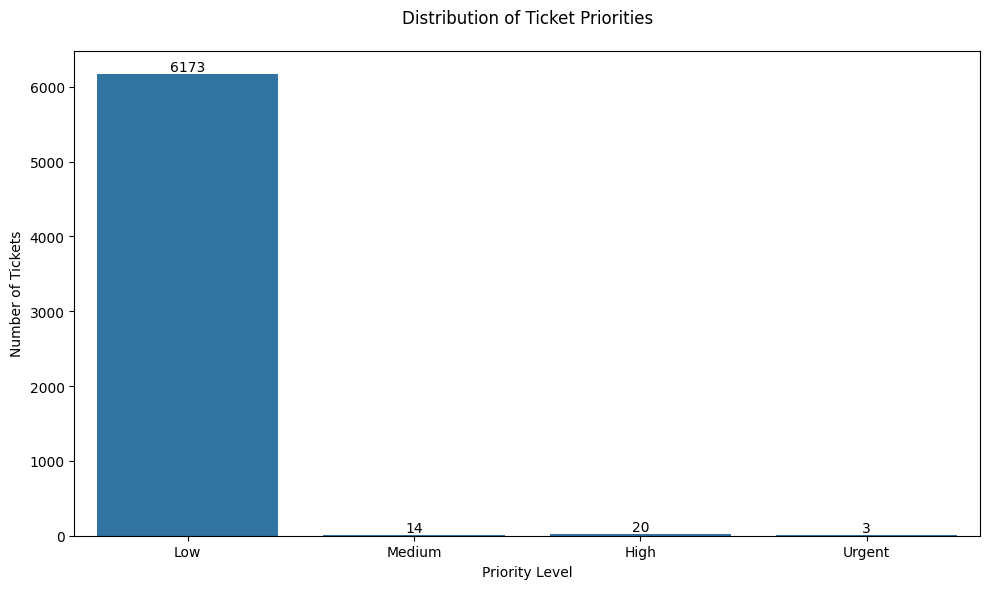

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10, 6))

# Create priority distribution plot
ax = sns.countplot(data=ticket_details_df, x='priority_category', order=['Low', 'Medium', 'High', 'Urgent'])

# Customize the plot
plt.title('Distribution of Ticket Priorities', pad=20)
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')

# Add value labels on top of each bar
for i in ax.containers:
    ax.bar_label(i)

# Adjust layout and display
plt.tight_layout()
plt.show()

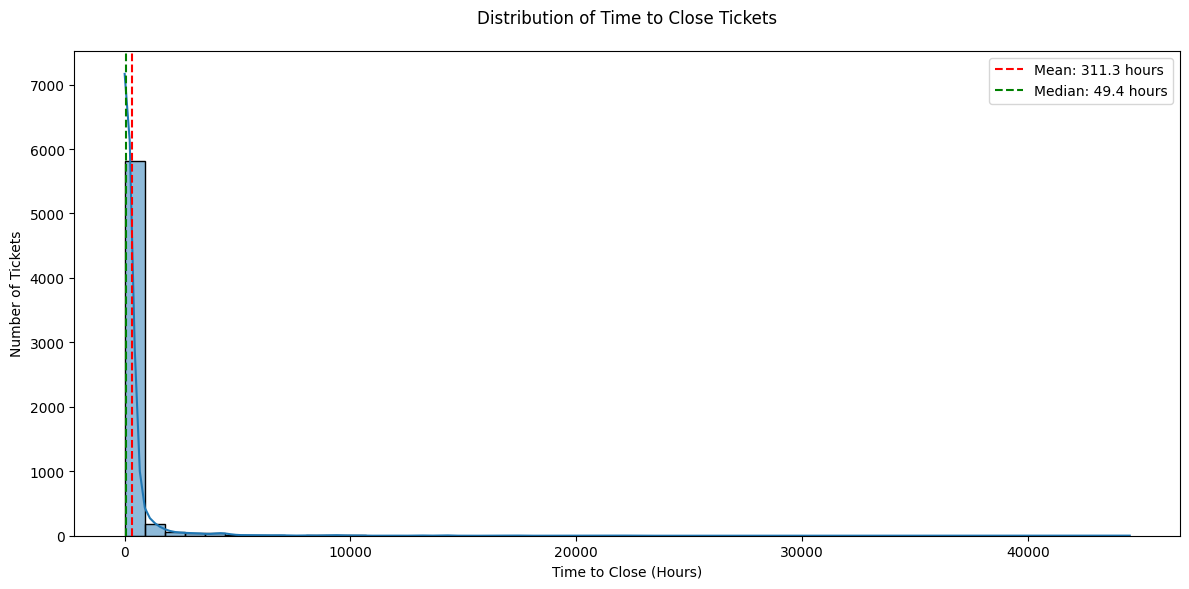

In [23]:
# Create a figure with larger size
plt.figure(figsize=(12, 6))

# Create distribution plot for time to close
sns.histplot(
    data=ticket_details_df,
    x='time_to_close_hours',
    bins=50,
    kde=True
)

# Add vertical lines for mean and median
plt.axvline(ticket_details_df['time_to_close_hours'].mean(), 
            color='red', 
            linestyle='--', 
            label=f"Mean: {ticket_details_df['time_to_close_hours'].mean():.1f} hours")
plt.axvline(ticket_details_df['time_to_close_hours'].median(), 
            color='green', 
            linestyle='--', 
            label=f"Median: {ticket_details_df['time_to_close_hours'].median():.1f} hours")

# Customize the plot
plt.title('Distribution of Time to Close Tickets', pad=20)
plt.xlabel('Time to Close (Hours)')
plt.ylabel('Number of Tickets')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

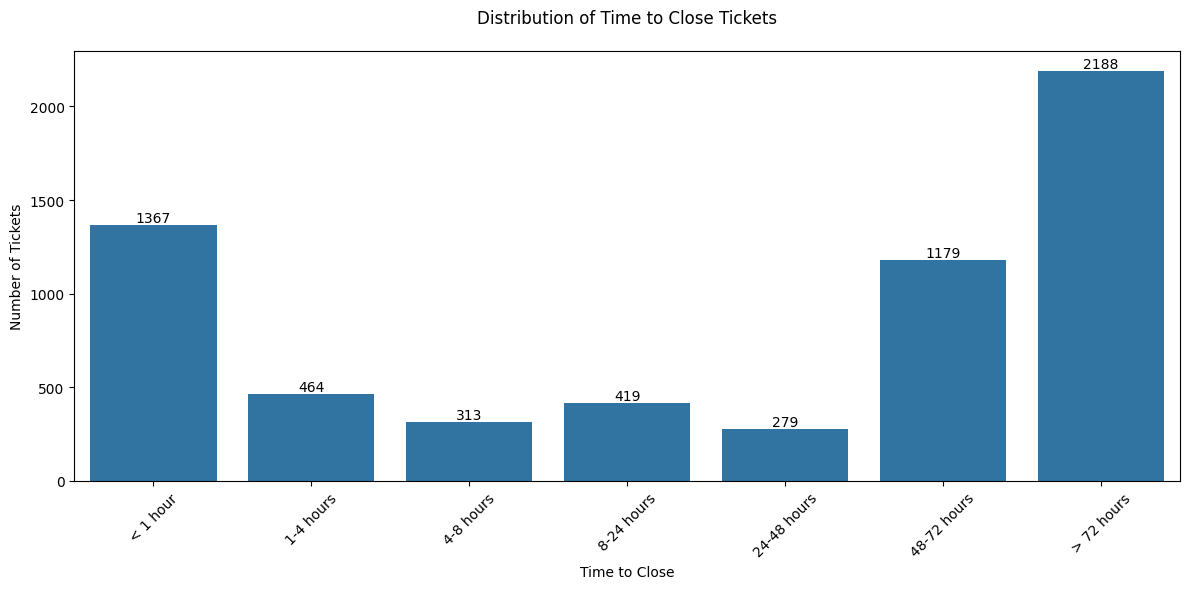


Exact counts per time band:
time_band
< 1 hour       1367
1-4 hours       464
4-8 hours       313
8-24 hours      419
24-48 hours     279
48-72 hours    1179
> 72 hours     2188
Name: count, dtype: int64


In [24]:
# Create time bands for better visualization
ticket_details_df['time_band'] = pd.cut(
    ticket_details_df['time_to_close_hours'],
    bins=[0, 1, 4, 8, 24, 48, 72, float('inf')],
    labels=['< 1 hour', '1-4 hours', '4-8 hours', '8-24 hours', '24-48 hours', '48-72 hours', '> 72 hours']
)

# Set figure size
plt.figure(figsize=(12, 6))

# Create the bar plot
ax = sns.countplot(data=ticket_details_df, x='time_band')

# Customize the plot
plt.title('Distribution of Time to Close Tickets', pad=20)
plt.xlabel('Time to Close')
plt.ylabel('Number of Tickets')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i in ax.containers:
    ax.bar_label(i)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print the exact counts for each band
print("\nExact counts per time band:")
print(ticket_details_df['time_band'].value_counts().sort_index())

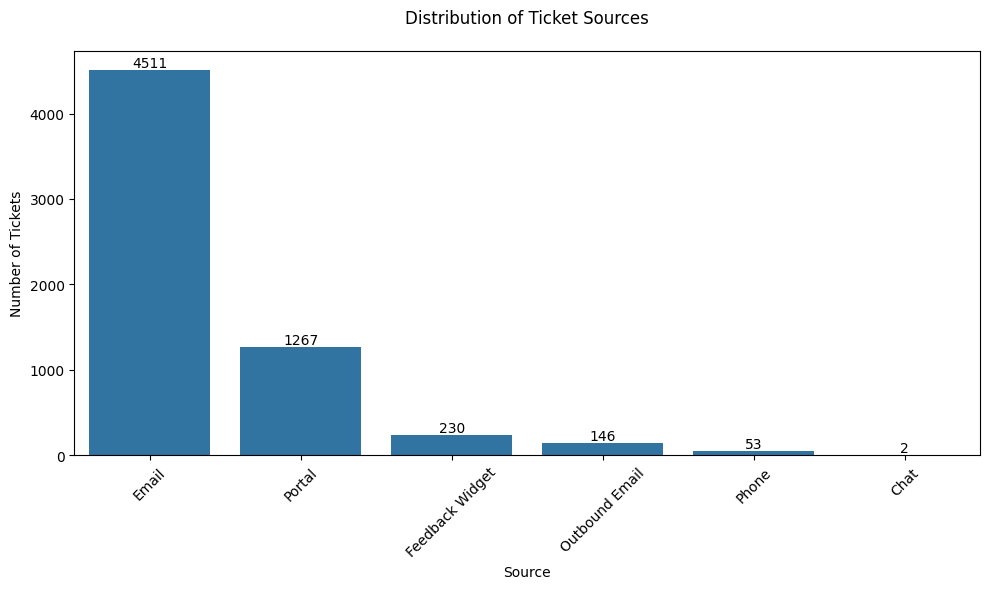


Source Distribution:
Email: 4511 tickets (72.7%)
Portal: 1267 tickets (20.4%)
Feedback Widget: 230 tickets (3.7%)
Outbound Email: 146 tickets (2.4%)
Phone: 53 tickets (0.9%)
Chat: 2 tickets (0.0%)


In [25]:
# First ensure our data is loaded and source is properly categorized
source_mapping = {
    1: 'Email',
    2: 'Portal',
    3: 'Phone',
    7: 'Chat',
    9: 'Feedback Widget',
    10: 'Outbound Email'
}

# Map numeric sources to their string values
ticket_details_df['source_name'] = ticket_details_df['source'].map(source_mapping)

# Create the visualization
plt.figure(figsize=(10, 6))

# Create source distribution plot
ax = sns.countplot(data=ticket_details_df, 
                  x='source_name',
                  order=ticket_details_df['source_name'].value_counts().index)

# Customize the plot
plt.title('Distribution of Ticket Sources', pad=20)
plt.xlabel('Source')
plt.ylabel('Number of Tickets')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i in ax.containers:
    ax.bar_label(i)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print the exact counts and percentages
source_counts = ticket_details_df['source_name'].value_counts()
source_percentages = ticket_details_df['source_name'].value_counts(normalize=True) * 100

print("\nSource Distribution:")
for source in source_counts.index:
    print(f"{source}: {source_counts[source]} tickets ({source_percentages[source]:.1f}%)")

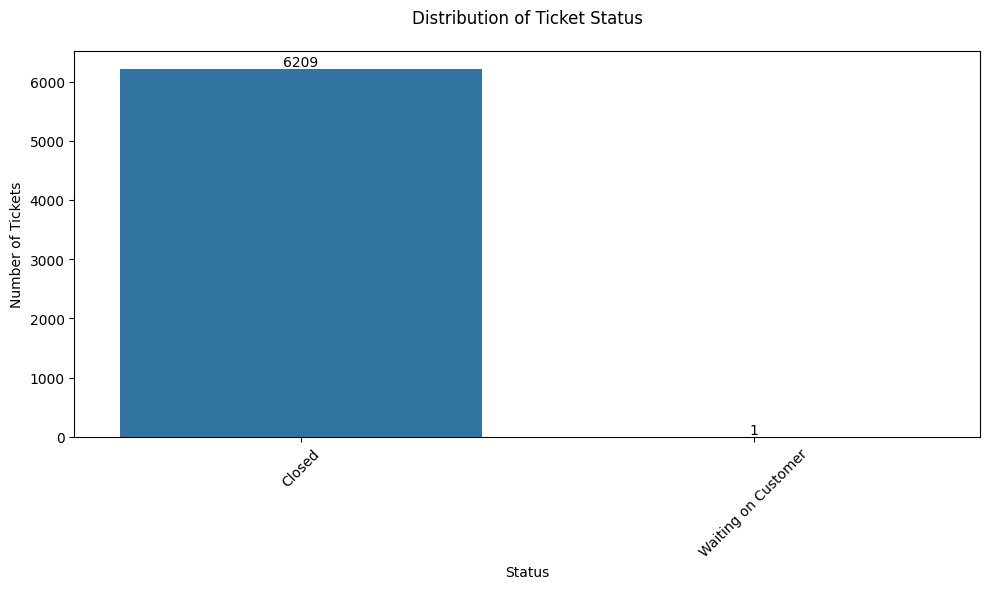


Status Distribution:
Closed: 6209 tickets (100.0%)
Waiting on Customer: 1 tickets (0.0%)


In [26]:
# First map status codes to meaningful names
status_mapping = {
    2: 'Open',
    3: 'Pending',
    4: 'Resolved',
    5: 'Closed',
    6: 'Waiting on Customer',
    7: 'Waiting on Third Party'
}

# Map numeric status to their string values
ticket_details_df['status_name'] = ticket_details_df['status'].map(status_mapping)

# Create the visualization
plt.figure(figsize=(10, 6))

# Create status distribution plot
ax = sns.countplot(data=ticket_details_df, 
                  x='status_name',
                  order=ticket_details_df['status_name'].value_counts().index)

# Customize the plot
plt.title('Distribution of Ticket Status', pad=20)
plt.xlabel('Status')
plt.ylabel('Number of Tickets')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i in ax.containers:
    ax.bar_label(i)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print the exact counts and percentages
status_counts = ticket_details_df['status_name'].value_counts()
status_percentages = ticket_details_df['status_name'].value_counts(normalize=True) * 100

print("\nStatus Distribution:")
for status in status_counts.index:
    print(f"{status}: {status_counts[status]} tickets ({status_percentages[status]:.1f}%)")

/var/folders/nd/z10gkxp14_vbcbgjmpzd69200000gn/T/ipykernel_1491/1419704753.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = ticket_details_df.groupby('priority_category')['time_to_close'].median()


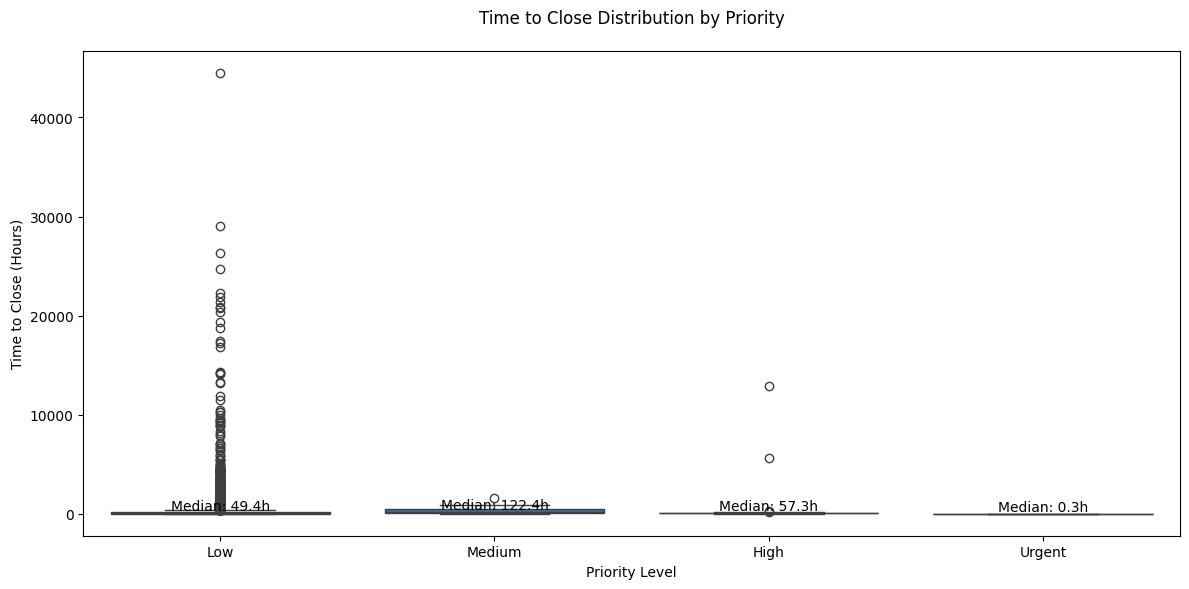

In [27]:
# Create box plot for Time to Close by Priority
plt.figure(figsize=(12, 6))

# Create the box plot
sns.boxplot(
    data=ticket_details_df,
    x='priority_category',
    y='time_to_close',
    order=['Low', 'Medium', 'High', 'Urgent']
)

# Customize the plot
plt.title('Time to Close Distribution by Priority', pad=20)
plt.xlabel('Priority Level')
plt.ylabel('Time to Close (Hours)')

# Add median values on top of each box
medians = ticket_details_df.groupby('priority_category')['time_to_close'].median()
for i, priority in enumerate(['Low', 'Medium', 'High', 'Urgent']):
    if priority in medians:
        plt.text(i, medians[priority], f'Median: {medians[priority]:.1f}h', 
                horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

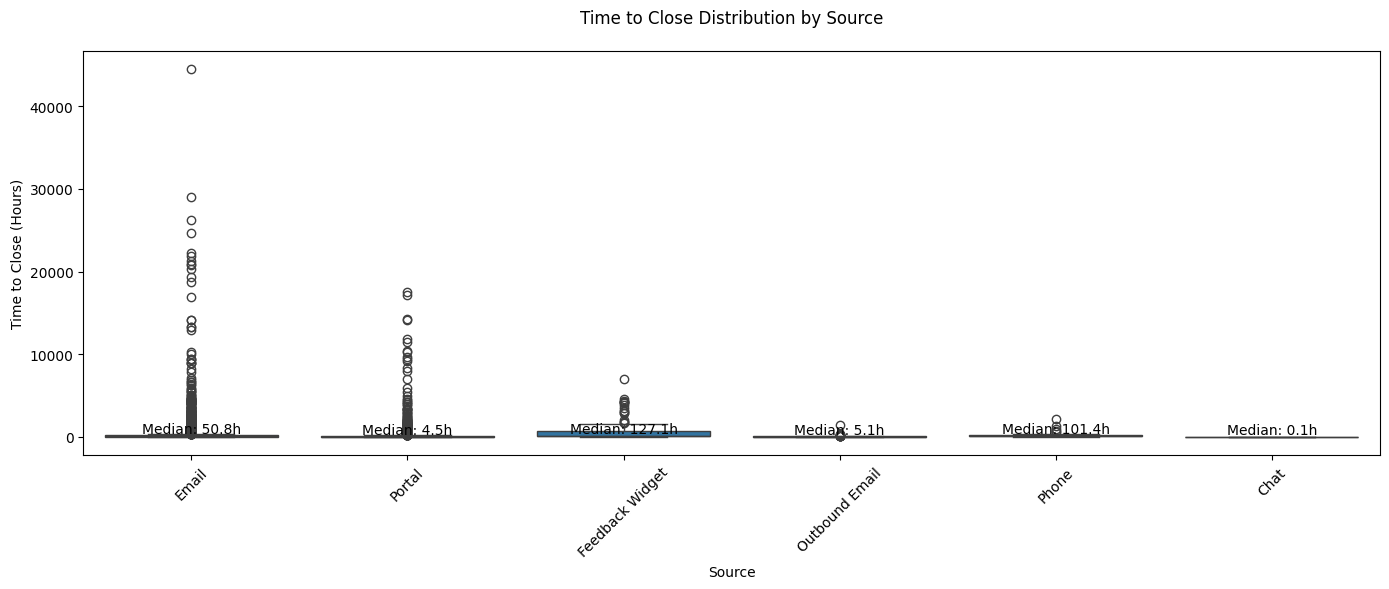

In [28]:
# Create box plot for Time to Close by Source
plt.figure(figsize=(14, 6))

# Create the box plot
sns.boxplot(
    data=ticket_details_df,
    x='source_name',
    y='time_to_close',
    order=ticket_details_df['source_name'].value_counts().index
)

# Customize the plot
plt.title('Time to Close Distribution by Source', pad=20)
plt.xlabel('Source')
plt.ylabel('Time to Close (Hours)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add median values on top of each box
medians = ticket_details_df.groupby('source_name')['time_to_close'].median()
for i, source in enumerate(ticket_details_df['source_name'].value_counts().index):
    if source in medians:
        plt.text(i, medians[source], f'Median: {medians[source]:.1f}h', 
                horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

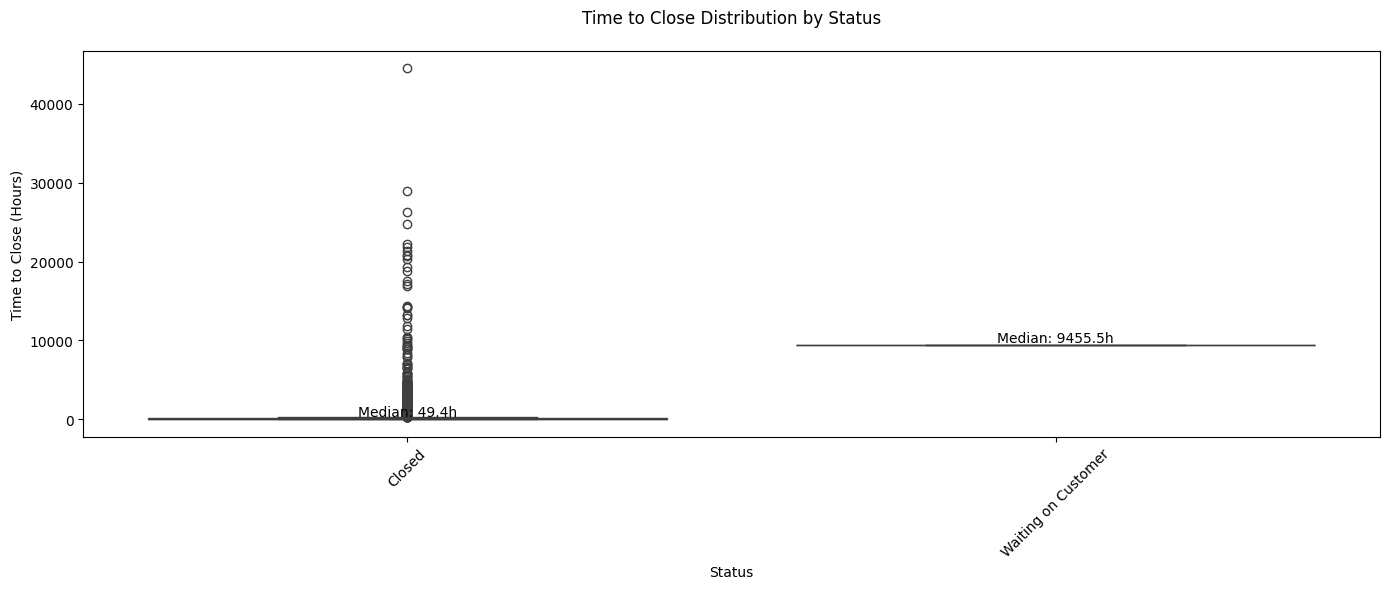

In [29]:
# Create box plot for Time to Close by Status
plt.figure(figsize=(14, 6))

# Create the box plot
sns.boxplot(
    data=ticket_details_df,
    x='status_name',
    y='time_to_close',
    order=ticket_details_df['status_name'].value_counts().index
)

# Customize the plot
plt.title('Time to Close Distribution by Status', pad=20)
plt.xlabel('Status')
plt.ylabel('Time to Close (Hours)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add median values on top of each box
medians = ticket_details_df.groupby('status_name')['time_to_close'].median()
for i, status in enumerate(ticket_details_df['status_name'].value_counts().index):
    if status in medians:
        plt.text(i, medians[status], f'Median: {medians[status]:.1f}h', 
                horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

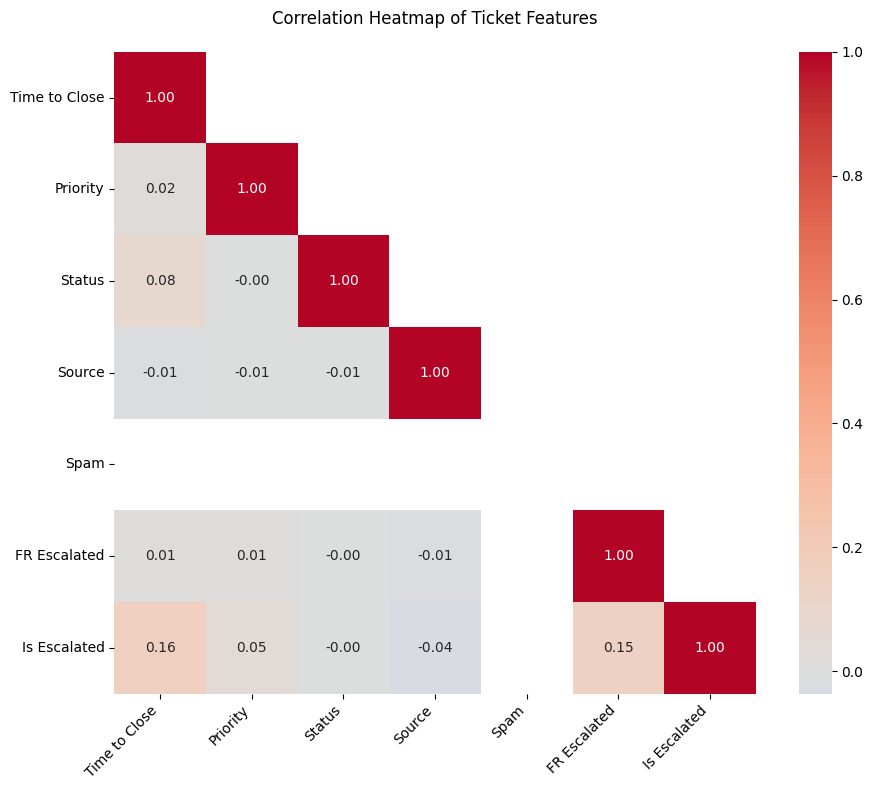


Strongest correlations with Time to Close:
is_escalated: 0.164
status_num: 0.079
priority_num: 0.019
fr_escalated: 0.015
source_num: -0.009
spam: nan


In [30]:
# Prepare the data for correlation analysis
# Convert categorical variables to numeric
ticket_details_df['priority_num'] = ticket_details_df['priority_category'].cat.codes
ticket_details_df['status_num'] = ticket_details_df['status_name'].astype('category').cat.codes
ticket_details_df['source_num'] = ticket_details_df['source_name'].astype('category').cat.codes

# Select features for correlation
features_for_correlation = [
    'time_to_close',
    'priority_num',
    'status_num',
    'source_num',
    'spam',
    'fr_escalated',
    'is_escalated',
]

# Create correlation matrix
correlation_matrix = ticket_details_df[features_for_correlation].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,  # Show correlation values
    cmap='coolwarm',  # Color scheme
    center=0,  # Center the colormap at 0
    fmt='.2f',  # Format correlation values to 2 decimal places
    square=True,  # Make cells square
    mask=np.triu(correlation_matrix, k=1).astype(bool),  # Show only lower triangle
)

# Customize labels
labels = [
    'Time to Close',
    'Priority',
    'Status',
    'Source',
    'Spam',
    'FR Escalated',
    'Is Escalated'
]
plt.xticks(np.arange(len(labels)) + 0.5, labels, rotation=45, ha='right')
plt.yticks(np.arange(len(labels)) + 0.5, labels, rotation=0)

plt.title('Correlation Heatmap of Ticket Features', pad=20)
plt.tight_layout()
plt.show()

# Print strongest correlations
print("\nStrongest correlations with Time to Close:")
correlations_with_time = correlation_matrix['time_to_close'].sort_values(ascending=False)
for feature, correlation in correlations_with_time.items():
    if feature != 'time_to_close':  # Skip self-correlation
        print(f"{feature}: {correlation:.3f}")

### Workload Analysis for Responders



=== Repeat Requester Analysis ===

Tickets per requester:
count    3798.000000
mean        1.635071
std         2.317230
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        64.000000
Name: ticket_count, dtype: float64

Number of repeat requesters (>3 tickets): 220
Percentage of requesters that are repeat: 5.8%


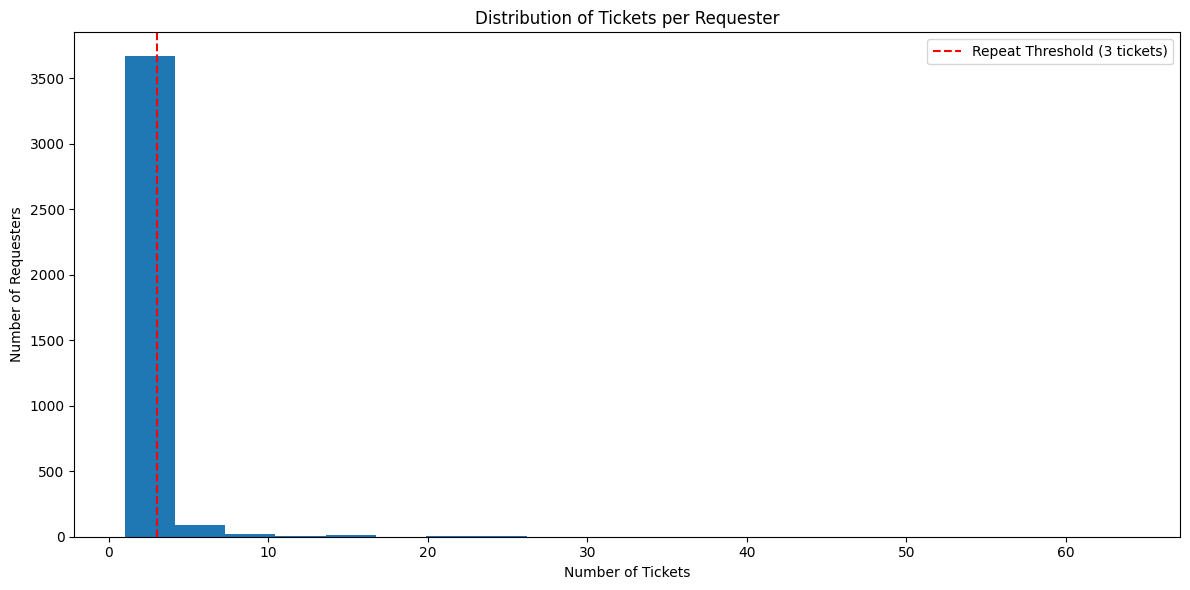


Top 10 requesters by ticket volume:
              ticket_count  avg_time_to_close  avg_priority  unique_sources
requester_id                                                               
12018372789             64              37.56          1.00               1
12034014734             60               6.14          1.00               1
12042125959             48             319.40          1.00               4
12038932610             45               6.24          1.00               1
12037336667             25              10.11          1.00               2
5021537993              24              50.22          1.25               2
12026986213             21              19.48          1.00               1
12002067892             20              20.33          1.00               1
12019028997             16             104.28          1.00               2
12058497077             16               0.25          1.00               1

=== Characteristics of Repeat Requester Tickets ==

In [31]:
# Calculate requester ticket frequency
requester_stats = ticket_details_df.groupby('requester_id').agg({
    'time_to_close': ['count', 'mean'],
    'priority': 'mean',
    'source': 'nunique'
}).round(2)

# Rename columns for clarity
requester_stats.columns = ['ticket_count', 'avg_time_to_close', 'avg_priority', 'unique_sources']

# Sort by number of tickets to identify frequent requesters
requester_stats = requester_stats.sort_values('ticket_count', ascending=False)

# Print basic statistics about repeat requesters
print("=== Repeat Requester Analysis ===")
print("\nTickets per requester:")
print(requester_stats['ticket_count'].describe())

# Define repeat requester threshold (e.g., more than 3 tickets)
repeat_threshold = 3
repeat_requesters = requester_stats[requester_stats['ticket_count'] > repeat_threshold]

print(f"\nNumber of repeat requesters (>{repeat_threshold} tickets): {len(repeat_requesters)}")
print(f"Percentage of requesters that are repeat: {(len(repeat_requesters)/len(requester_stats))*100:.1f}%")

# Create visualization
plt.figure(figsize=(12, 6))

# Create histogram of tickets per requester
plt.hist(requester_stats['ticket_count'], bins=20)
plt.title('Distribution of Tickets per Requester')
plt.xlabel('Number of Tickets')
plt.ylabel('Number of Requesters')

# Add vertical line for repeat threshold
plt.axvline(x=repeat_threshold, color='r', linestyle='--', 
            label=f'Repeat Threshold ({repeat_threshold} tickets)')

plt.legend()
plt.tight_layout()
plt.show()

# Print top repeat requesters
print("\nTop 10 requesters by ticket volume:")
print(requester_stats.head(10))

# Analyze characteristics of repeat requester tickets
repeat_requester_tickets = ticket_details_df[
    ticket_details_df['requester_id'].isin(repeat_requesters.index)
]

print("\n=== Characteristics of Repeat Requester Tickets ===")
print("\nPriority Distribution:")
print(repeat_requester_tickets['priority_category'].value_counts(normalize=True) * 100)

print("\nSource Distribution:")
print(repeat_requester_tickets['source_name'].value_counts(normalize=True) * 100)

print("\nStatus Distribution:")
print(repeat_requester_tickets['status_name'].value_counts(normalize=True) * 100)

# Compare resolution times
print("\n=== Resolution Time Comparison ===")
print("Average resolution time for repeat requesters:", 
      f"{repeat_requester_tickets['time_to_close'].mean():.2f}")
print("Average resolution time for all tickets:", 
      f"{ticket_details_df['time_to_close'].mean():.2f}")

### Interaction Analysis

=== Email Participant Statistics ===
cc_emails: 9.98 participants on average
fwd_emails: 2.04 participants on average
reply_cc_emails: 8.89 participants on average
ticket_cc_emails: 7.14 participants on average

Tickets with CC participants: 6210 (100.00%)


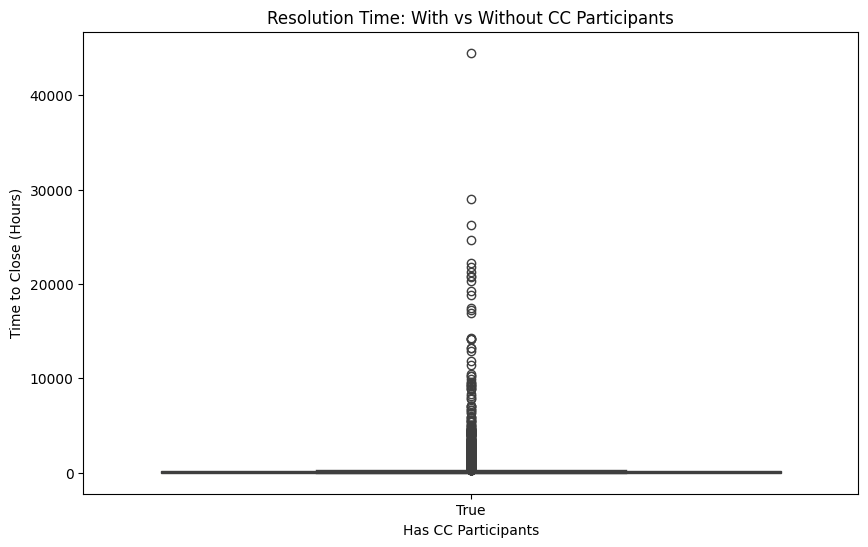

In [32]:
# First, let's analyze email participants and communication patterns
communication_stats = ticket_details_df.agg({
    'cc_emails': lambda x: x.str.len().mean(),  # Average number of CC'd participants
    'fwd_emails': lambda x: x.str.len().mean(),  # Average number of forwarded emails
    'reply_cc_emails': lambda x: x.str.len().mean(),  # Average number of reply CCs
    'ticket_cc_emails': lambda x: x.str.len().mean(),  # Average number of ticket CCs
}).round(2)

print("=== Email Participant Statistics ===")
for metric, value in communication_stats.items():
    print(f"{metric}: {value:.2f} participants on average")

# Calculate tickets with CC participants
tickets_with_cc = ticket_details_df[ticket_details_df['cc_emails'].str.len() > 0]
print(f"\nTickets with CC participants: {len(tickets_with_cc)} ({len(tickets_with_cc)/len(ticket_details_df)*100:.2f}%)")

# Analyze impact of CC'd participants on resolution time
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=ticket_details_df,
    x=ticket_details_df['cc_emails'].str.len() > 0,
    y='time_to_close'
)
plt.title('Resolution Time: With vs Without CC Participants')
plt.xlabel('Has CC Participants')
plt.ylabel('Time to Close (Hours)')
plt.show()



### Time-based Analysis

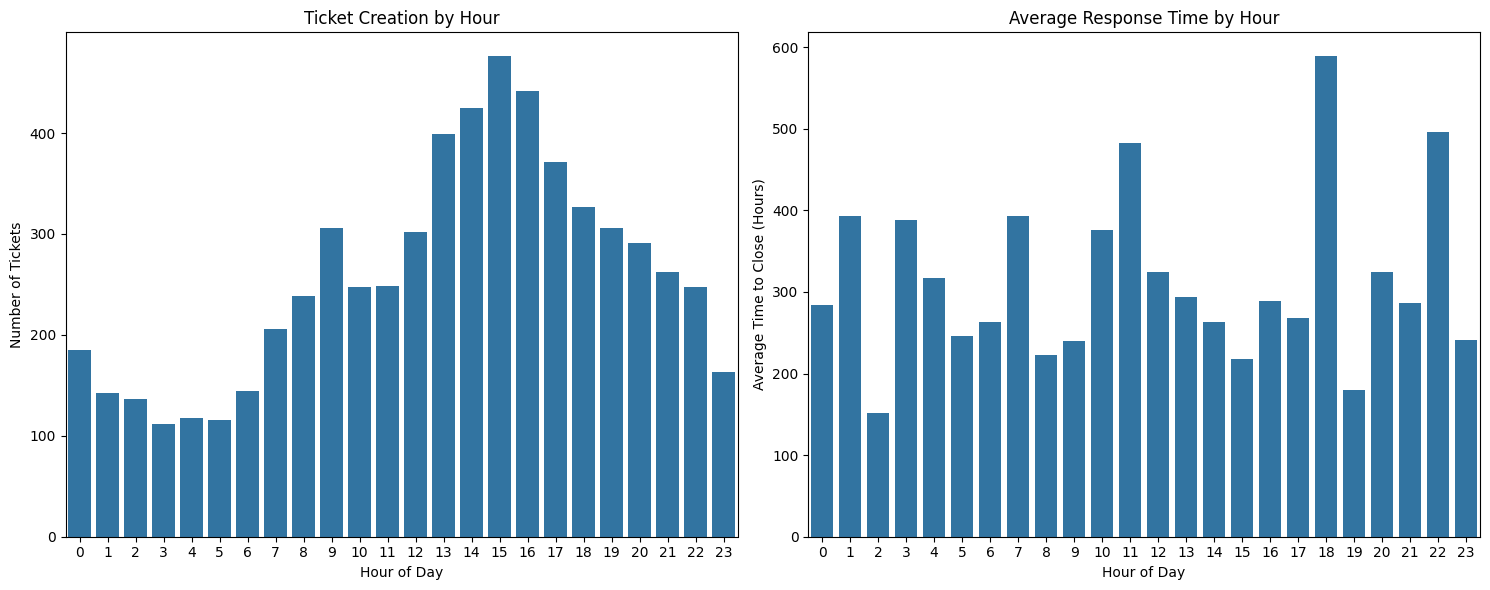

=== Time-based Analysis ===

Business Hours vs Non-Business Hours:
Business Hours Tickets: 3216 (51.8%)
Average response time during business hours: 293.50 hours
Average response time outside business hours: 330.35 hours


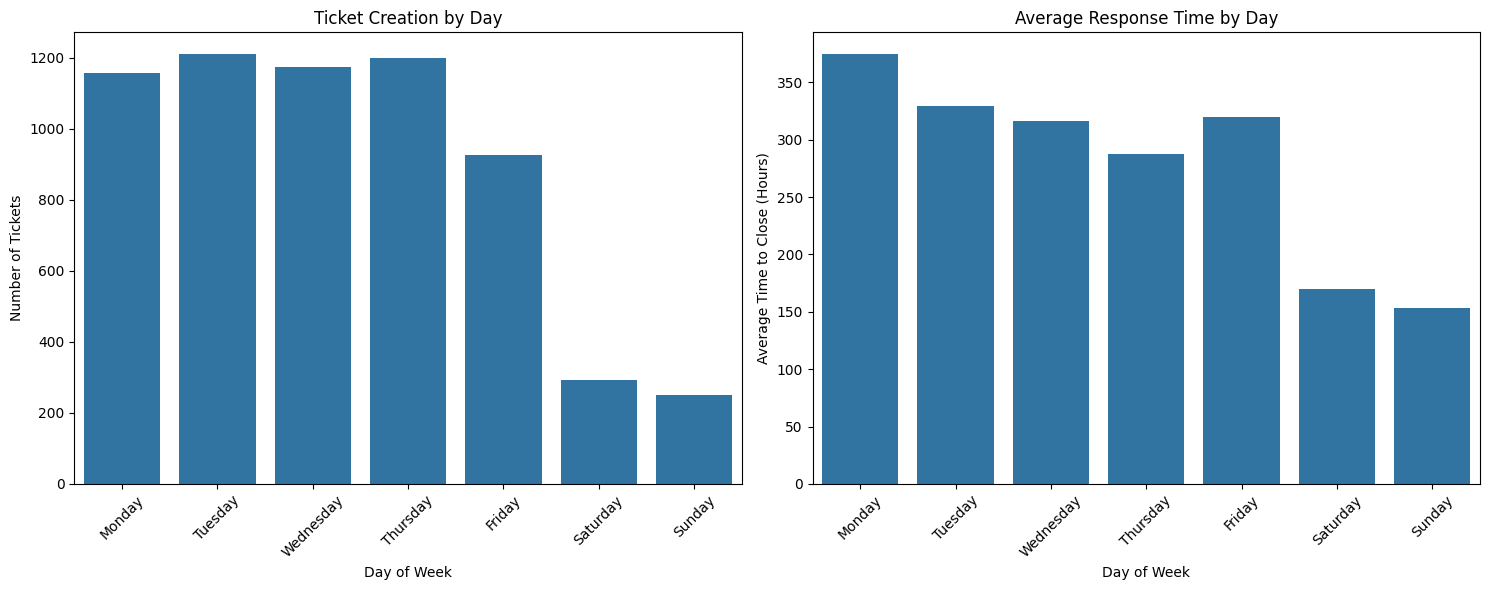


Weekend vs Weekday Analysis:
Weekend Tickets: 543 (8.7%)
Average response time on weekends: 162.14 hours
Average response time on weekdays: 325.55 hours

Peak Hours:
Hour 15:00 - 476 tickets
Hour 16:00 - 442 tickets
Hour 14:00 - 425 tickets


In [33]:
# Time-based analysis
ticket_details_df['hour_created'] = ticket_details_df['created_at'].dt.hour
ticket_details_df['day_created'] = ticket_details_df['created_at'].dt.day_name()
ticket_details_df['is_weekend'] = ticket_details_df['created_at'].dt.weekday.isin([5, 6])
ticket_details_df['is_business_hours'] = ticket_details_df['hour_created'].between(9, 17)

# Hourly distribution
plt.figure(figsize=(15, 6))

# Create subplot for hourly ticket creation
plt.subplot(1, 2, 1)
hourly_tickets = ticket_details_df['hour_created'].value_counts().sort_index()
sns.barplot(x=hourly_tickets.index, y=hourly_tickets.values)
plt.title('Ticket Creation by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tickets')

# Create subplot for hourly response times
plt.subplot(1, 2, 2)
hourly_response = ticket_details_df.groupby('hour_created')['time_to_close'].mean()
sns.barplot(x=hourly_response.index, y=hourly_response.values)
plt.title('Average Response Time by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Time to Close (Hours)')

plt.tight_layout()
plt.show()

# Print statistics
print("=== Time-based Analysis ===")
print("\nBusiness Hours vs Non-Business Hours:")
print(f"Business Hours Tickets: {ticket_details_df['is_business_hours'].sum()} "
      f"({ticket_details_df['is_business_hours'].mean()*100:.1f}%)")
print(f"Average response time during business hours: "
      f"{ticket_details_df[ticket_details_df['is_business_hours']]['time_to_close'].mean():.2f} hours")
print(f"Average response time outside business hours: "
      f"{ticket_details_df[~ticket_details_df['is_business_hours']]['time_to_close'].mean():.2f} hours")

# Day of week analysis
plt.figure(figsize=(15, 6))

# Create subplot for daily ticket creation
plt.subplot(1, 2, 1)
daily_tickets = ticket_details_df['day_created'].value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_tickets = daily_tickets.reindex(day_order)
sns.barplot(x=daily_tickets.index, y=daily_tickets.values)
plt.title('Ticket Creation by Day')
plt.xlabel('Day of Week')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)

# Create subplot for daily response times
plt.subplot(1, 2, 2)
daily_response = ticket_details_df.groupby('day_created')['time_to_close'].mean()
daily_response = daily_response.reindex(day_order)
sns.barplot(x=daily_response.index, y=daily_response.values)
plt.title('Average Response Time by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Time to Close (Hours)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print weekend vs weekday statistics
print("\nWeekend vs Weekday Analysis:")
print(f"Weekend Tickets: {ticket_details_df['is_weekend'].sum()} "
      f"({ticket_details_df['is_weekend'].mean()*100:.1f}%)")
print(f"Average response time on weekends: "
      f"{ticket_details_df[ticket_details_df['is_weekend']]['time_to_close'].mean():.2f} hours")
print(f"Average response time on weekdays: "
      f"{ticket_details_df[~ticket_details_df['is_weekend']]['time_to_close'].mean():.2f} hours")

# Calculate peak hours
peak_hours = hourly_tickets.nlargest(3)
print("\nPeak Hours:")
for hour, count in peak_hours.items():
    print(f"Hour {hour:02d}:00 - {count} tickets")